In [1]:
#Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

In [2]:
csv = 'mergedworms.csv'# Read the CSV file
data = pd.read_csv(csv)

np.random.seed(42)

## Lifespan Estimation

In [72]:
def predict_lifespan(data, model_select="linear", test_size=0.2, random_state=42):
    """
    Predict the lifespan of worms based on behavioral data.

    Args:
        df: DataFrame containing the dataset.
        model_select: Choice of regression model ('linear', 'random_forest', 'xgboost').
        test_size: Fraction of data to use as test set.
        random_state: Seed for reproducibility.

    Returns:
        None (prints evaluation metrics and feature importances for tree-based models).
    """
    df = data.copy()
    # csv = 'mergedworms.csv'# Read the CSV file
    # df = pd.read_csv(csv)


    # Preprocess lifespan (convert from hours to days)
    df['lifespan'] = df['lifespan'] / 24

    # Extract features (X), target (y), and groups (worm_id)
    # X = df.drop(columns=['id', 'worm_id', 'lifespan', 'average_distance_per_frame', 'maximal_distance_traveled', 'average_acceleration'])
    X = df.drop(columns = ['lifespan', 'worm_id'])
    y = df['lifespan']
    groups = df['worm_id']

    # Split the dataset into training and testing based on worm_id grouping
    gkf = GroupKFold(n_splits=int(1 / test_size))
    train_idx, test_idx = next(gkf.split(X, y, groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # sample imputing (NEED TO IMPROVE) -- ONLY TEMPORARY
    if np.isnan(X_train).any().any() or np.isnan(X_test).any().any():
        # Impute missing values with the median
        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.fit_transform(X_test)

    # Initialize the model
    if model_select == "linear":
        model = LinearRegression()
    elif model_select == "random_forest":
        model = RandomForestRegressor(random_state=random_state)
    elif model_select == "xgboost":
        model = XGBRegressor(random_state=random_state, n_estimators=100, learning_rate=0.05)
    else:
        raise Exception("Invalid model selected. Options are 'linear', 'random_forest', 'xgboost'.")

    # Scale features for linear models
    if model_select == "linear":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Train the model
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")

    # Feature importance for tree-based models
    if model_select in ["random_forest", "xgboost"]:
        importances = model.feature_importances_
        feature_importances = sorted(zip(X.columns, importances), key=lambda x: -x[1])
        print("\nFeature Importances:")
        for feature, importance in feature_importances:
            print(f"{feature}: {importance:.4f}")

    import matplotlib.pyplot as plt
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.xlabel("Actual Lifespan (days)")
    plt.ylabel("Predicted Lifespan (days)")
    plt.title("Predicted vs. Actual Lifespan")
    plt.show()

    print("y_pred", y_pred)
    print("y_test", y_test)

    return model, mse, r2

Mean Squared Error: 41.36
R^2 Score: 0.13


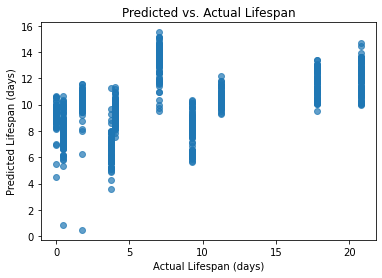

y_pred [12.32985292 12.06921436 12.80196398 11.78597843 12.51144722 12.51022603
 11.32607914 11.37450156 12.3366005  12.64353289 11.91991715 11.68769782
 12.57469863 12.40575294 12.55090244 12.49369693 12.30368511 12.03232625
 12.71562021 13.20010708 12.65919535 13.53361648 11.72936833 12.82337372
 13.2390032  12.85750715 13.43579138 13.36790903 13.59991704 13.64347201
 12.80754042 12.37214814 13.6182938  13.19733588 13.27996278 13.34877473
 12.94209806 12.84698669 13.96218244 13.62125886 14.46459165 12.82673245
 12.63807544 11.80587562 12.32201702 12.6143082  12.36437957 10.76635468
 10.92739425 14.68863247 11.02141925 13.15487381 11.28325761 11.50691735
 11.76161658 11.1439852  11.0485878  10.61751765 12.17129634 13.38926021
 12.39713697 11.1989836  11.18802032 11.11550288 10.79205819 10.81671208
 10.90919198 11.00063442 10.95958252 10.59364278 10.57728986 10.39422539
 10.79476936  9.9345664  10.27736019 10.17232092 10.03281066 10.26976021
 10.95374959 11.42597778 11.73815966 11.0477

In [73]:
model, mse, r2 = predict_lifespan(data)

Mean Squared Error: 45.04
R^2 Score: 0.05

Feature Importances:
total_distance_traveled: 0.1994
average_angular_speed: 0.1556
drugged: 0.1043
roaming_fraction: 0.0838
distance_traveled_bin: 0.0777
std/mean: 0.0731
std_speed: 0.0675
average_change_in_pixels: 0.0674
average_speed: 0.0595
time_elapsed_(hours): 0.0591
group: 0.0527


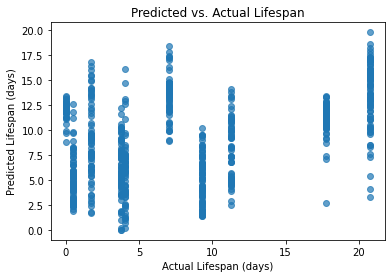

In [46]:
model, mse, r2 = predict_lifespan(data, model_select="random_forest")

Mean Squared Error: 46.42
R^2 Score: 0.02

Feature Importances:
drugged: 0.3777
time_elapsed_(hours): 0.0871
total_distance_traveled: 0.0837
average_angular_speed: 0.0825
distance_traveled_bin: 0.0743
roaming_fraction: 0.0679
group: 0.0551
std_speed: 0.0489
std/mean: 0.0475
average_speed: 0.0397
average_change_in_pixels: 0.0356


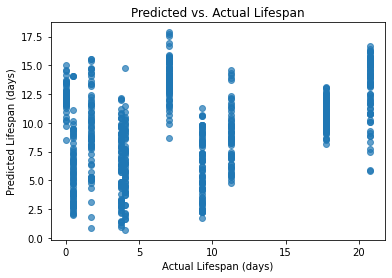

In [48]:
model, mse, r2 = predict_lifespan(data, model_select="xgboost")

In [78]:
csv = 'mergedworms.csv'# Read the CSV file
data = pd.read_csv(csv)

aggregated_data = data.groupby("worm_id").agg({
    "worm_id": "first",
    "group": "first",  # Assuming group is constant per worm
    "average_speed": ["mean", "median", "min", "max"],
    "maximal_distance_traveled": "max",  # Keep max as it may capture peaks
    "average_change_in_pixels": ["mean", "std", "median", "min", "max"],
    "average_angular_speed": ["mean", "std", "min", "max"],
    "distance_traveled_bin": ["mean", "std"],
    "time_elapsed_(hours)": "max",  # Keep max as it's likely cumulative
    "std_speed": "mean",  # Capture average variability
    "std/mean": "mean",  # Keep mean of std/mean as a ratio metric
    "roaming_fraction": "mean",  # Capture average roaming behavior
    "lifespan": "first",  # Lifespan is constant per worm
    "drugged": "first"  # Assuming drugged is constant per worm
})
aggregated_data.columns = ["_".join(col).strip() for col in aggregated_data.columns]
aggregated_data.rename(columns={"lifespan_first": "lifespan", "worm_id_first": "worm_id"}, inplace=True)

In [82]:
# aggregated_data.columns
aggregated_data['lifespan']

worm_id
1     354.497222
2     498.496111
3     498.496111
4       0.001111
5     498.496111
6     426.496667
7       0.007778
8     498.496111
9     336.460000
10    498.496111
11    168.498333
12    300.488889
13    324.422222
14      0.448889
15     60.463333
16    354.497222
17    426.496667
18    270.500000
19     12.033333
20      0.463889
21     66.480000
22     72.403333
23    330.393889
24    222.500000
25     12.469444
26     24.482222
27    498.496111
28    426.496667
29     42.037778
30    426.496667
31    252.038889
32    384.473889
33     96.467778
34      0.043333
35    258.213333
36      0.007778
37    498.496111
38    288.463889
39    354.497222
40    426.496667
41      0.001111
42     90.027222
43      0.001111
44    396.005000
45    294.195556
46      0.495556
47     12.301111
48      0.105556
Name: lifespan, dtype: float64

In [80]:
# Check for high correlation and avoid duplicates
# Iterate through the upper triangle of the correlation matrix (to avoid duplicates)
correlation_matrix = aggregated_data.corr()

# Threshold for high correlation
threshold = 0.75

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):  # Upper triangle
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            correlation_value = correlation_matrix.iloc[i, j]
            print(f"Highly correlated: {col1} and {col2} with correlation {correlation_value:.2f}")

Highly correlated: average_speed_mean and average_speed_max with correlation 0.78
Highly correlated: average_speed_mean and distance_traveled_bin_mean with correlation 0.79
Highly correlated: average_speed_mean and distance_traveled_bin_std with correlation 0.79
Highly correlated: average_speed_median and distance_traveled_bin_mean with correlation 0.78
Highly correlated: maximal_distance_traveled_max and distance_traveled_bin_mean with correlation 0.86
Highly correlated: average_change_in_pixels_mean and average_change_in_pixels_max with correlation 0.79
Highly correlated: distance_traveled_bin_mean and distance_traveled_bin_std with correlation 0.76


Mean Squared Error: 126.05
R^2 Score: -1.90

Feature Importances:
average_change_in_pixels_max: 0.1590
average_angular_speed_max: 0.1263
average_change_in_pixels_mean: 0.1247
maximal_distance_traveled_max: 0.0983
average_angular_speed_std: 0.0969
group_first: 0.0853
average_speed_max: 0.0750
average_change_in_pixels_std: 0.0628
distance_traveled_bin_std: 0.0612
std_speed_mean: 0.0280
average_speed_median: 0.0252
average_change_in_pixels_median: 0.0166
average_angular_speed_min: 0.0134
roaming_fraction_mean: 0.0092
time_elapsed_(hours)_max: 0.0070
average_speed_mean: 0.0068
average_speed_min: 0.0041
average_change_in_pixels_min: 0.0001
average_angular_speed_mean: 0.0000
distance_traveled_bin_mean: 0.0000
std/mean_mean: 0.0000
drugged_first: 0.0000


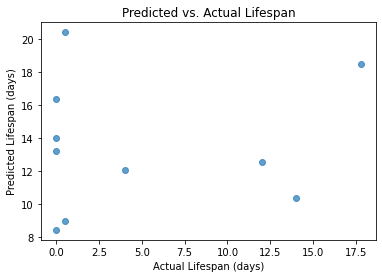

y_pred [16.400007  10.377701  13.219747   9.0119295 20.437971  18.501202
 12.082437  12.597029  14.055004   8.453772 ]
y_test worm_id
4      0.000046
9     14.019167
14     0.018704
19     0.501389
25     0.519560
28    17.770694
33     4.019491
38    12.019329
43     0.000046
48     0.004398
Name: lifespan, dtype: float64


In [81]:
model, mse, r2 = predict_lifespan(aggregated_data, model_select="xgboost")